# Lab 4 - Lane Detection & Image Processing

Your Duckiebot's camera produces a 640x480 picture about thirty times a second.
Somewhere in that picture are the lane markings, and somewhere in the numbers
that describe them is the answer to the only question the robot actually cares
about: **Where am I in the lane, and which way am I facing in it?**

This notebook covers the detection half: turning an image into a list of line
segments, each one labeled with a color and pointed the right way round.

**Sections 1-7 are what you port into your ROS node** (Parts II and III of the
lab). Section 8 is already in the node, as `_orient`.

---

## The pipeline

```
   camera image
        |
   1. resize + crop
   2. convert to HSV
   3. threshold each color
   4. clean up with morphology
   5. find edges
   6. keep edges inside each mask
   7. fit line segments
   8. orient each segment
```

In [5]:
%pip install --quiet numpy "opencv-python<5" matplotlib

Note: you may need to restart the kernel to use updated packages.


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Sample images. Your own captures go here too.
DATA = "data"

print("OpenCV", cv2.__version__)


def show(*images, titles=None, size=4, cmap=None, ticks=False):
    '''Draw one or more images side by side, converting BGR to RGB as needed.
    ticks=True keeps the pixel axes, for reading off (x, y).'''
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(size * n, size))
    axes = np.atleast_1d(axes)
    for ax, img in zip(axes, images):
        if img.ndim == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap=cmap or "gray", vmin=0, vmax=255)
        if not ticks:
            ax.axis("off")
    if titles:
        for ax, t in zip(axes, titles):
            ax.set_title(t, fontsize=10)
    plt.tight_layout()
    plt.show()

def draw(image, lines, color=(255, 0, 0)):
    out = image.copy()
    # HoughLinesP gives Nx1x4 in OpenCV 4, Nx4 in OpenCV 5, and None for no lines.
    if lines is None:
        return out
    for x1, y1, x2, y2 in np.reshape(lines, (-1, 4)):
        cv2.line(out, (x1, y1), (x2, y2), color, 1, cv2.LINE_AA)
    return out

OpenCV 4.14.0


## 1. An image is just an array

Load one and look at what you actually have.

type    <class 'numpy.ndarray'>
shape   (480, 640, 3)  <- (rows, columns, channels) = (height, width, 3)
dtype   uint8  <- one byte per channel, so 0..255
[[ 61  56  53]
 [ 61  56  53]
 [ 61  56  53]
 ...
 [101  91  91]
 [105  95  95]
 [109  99  99]]


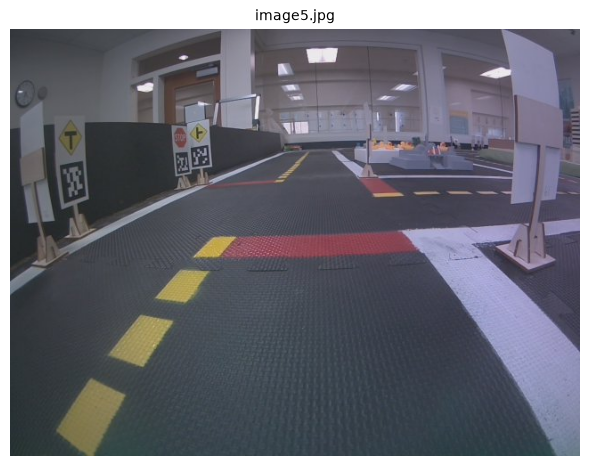

In [ ]:
# Any image in data/ works here, including your own captures.
bgr = cv2.imread(f"{DATA}/image5.jpg")
print("type   ", type(bgr))
print("shape  ", bgr.shape, " <- (rows, columns, channels) = (height, width, 3)")
print("dtype  ", bgr.dtype, " <- one byte per channel, so 0..255")

show(bgr, titles=["image5.jpg"], size=6)

**OpenCV stores color as B, G, R** - the reverse of the R, G, B order almost
everything else uses. `imread` gives you BGR, `imshow` in matplotlib expects
RGB, which is why `show()` above converts.

### Resizing and cropping

Two separate reasons for those two steps, and it is worth keeping them apart:

* Resize is about speed - What rate can your computer process these images at? Smaller images process faster.
* Crop is about relevance - What part of the image do you want to see?

Small.shape[0]:  480
original 640x480 = 307,200 pixels
resized  640x480 = 307,200 pixels
cropped  640x264 = 168,960 pixels

that is 2x less data per frame


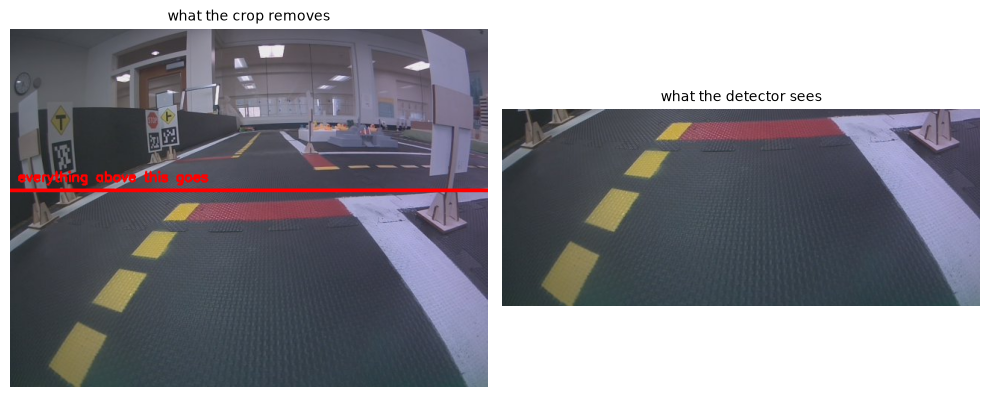

In [74]:
# TODO: Tune parameters to what you think it should be for your bot.
IMG_SIZE = (640, 480)     # (width, height). The original is (640, 480); keep its aspect ratio.
TOP_CUTOFF =   0.45   # fraction of top of image to throw away (to remove non-road or far away road)

# Resize
original_size = bgr.shape[1], bgr.shape[0]
# print("original size: ", original_size)
if original_size != IMG_SIZE:
    print(f"resizing {original_size} -> {IMG_SIZE}")
    small = cv2.resize(bgr, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    print("small.shape: ", small.shape)
    
else:
    small = bgr
    print("Small.shape[0]: ", small.shape[0])

# Crop
CUTOFF_ROWS = int(TOP_CUTOFF * small.shape[0])
# print("Small array: ", small)
cropped =   small[CUTOFF_ROWS: small.shape[0], :, :]  # TODO: slice the top CUTOFF_ROWS rows off `small`


print(f"original {bgr.shape[1]}x{bgr.shape[0]} = {bgr.shape[0]*bgr.shape[1]:,} pixels")
print(f"resized  {small.shape[1]}x{small.shape[0]} = {small.shape[0]*small.shape[1]:,} pixels")
print(f"cropped  {cropped.shape[1]}x{cropped.shape[0]} = {cropped.shape[0]*cropped.shape[1]:,} pixels")
print(f"\nthat is {bgr.size / cropped.size:.0f}x less data per frame")

# Crop line drawn on the full-size image to see what is being thrown away.
marked = bgr.copy()
y = int(TOP_CUTOFF * bgr.shape[0])
cv2.line(marked, (0, y), (bgr.shape[1], y), (0, 0, 255), 3)
cv2.putText(marked, "everything above this goes", (10, y - 12),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

show(marked, cropped, titles=["what the crop removes", "what the detector sees"], size=5)

## 2. Why HSV and not RGB

You are about to say "this pixel is white" and "this pixel is yellow". Try to
write that rule in BGR and you will find it is a mess, because in BGR the
*brightness* of a color and the *color itself* are tangled together across
all three numbers. A yellow line in shadow and the same line in sunlight have
completely different BGR values.

<img src="https://thumb.wikimedia.org/wikipedia/commons/thumb/8/83/RGB_Cube_Show_lowgamma_cutout_b.png/500px-RGB_Cube_Show_lowgamma_cutout_b.png" alt="RGB color cube" width="300">

*The RGB color space as a cube: every axis mixes color and brightness together.*

HSV pulls them apart:

<img src="https://thumb.wikimedia.org/wikipedia/commons/thumb/3/33/HSV_color_solid_cylinder_saturation_gray.png/500px-HSV_color_solid_cylinder_saturation_gray.png" alt="HSV color cylinder" width="300">

*The HSV color space as a cylinder: hue is the angle, saturation the radius, value the height.*

| channel | meaning | OpenCV range |
|---|---|---|
| **H**ue | which color it is, as an angle round the color wheel | 0-179 |
| **S**aturation | how vivid, from gray to pure color | 0-255 |
| **V**alue | how bright | 0-255 |

Note H only goes to **179**, not 359 - it is an angle halved to fit in a byte.
It also **wraps**: 179 and 0 are neighbours. That matters in a moment.

These three grayscale images show the H, S and V channels on their own. Use them to get an intuition for what separates white from yellow. The axes are in pixels, for picking points in the next cell.

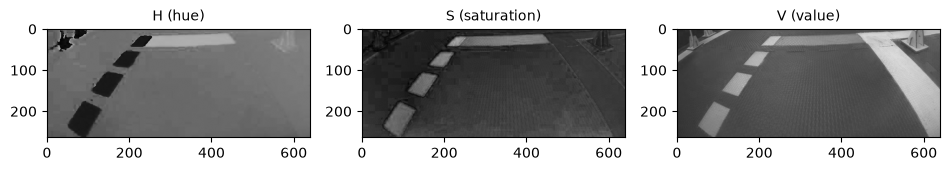

In [76]:
hsv = cv2.cvtColor(cropped, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

show(h, s, v, titles=["H (hue)", "S (saturation)", "V (value)"], size=3.2, ticks=True)

                           H     S     V
road                     165     9    56
white line               125    51    85
yellow line              165     9    56
red line                 113    37    83


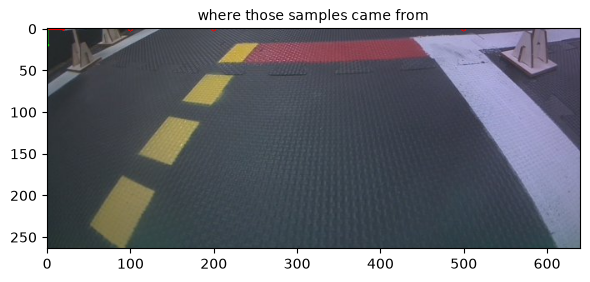

In [ ]:
# TODO: Read the actual numbers off four places in the image.
# Fill in each as an (x, y) tuple, using the pixel axes above.
points = {
    "road":      [100, 0]        ,
    "white line":    [500, 0]    ,
    "yellow line":     [100, 0]  ,
    "red line":   [200, 0]       ,
}

# Print the HSV values for the points of interest.
print(f"{'':22s} {'H':>5s} {'S':>5s} {'V':>5s}")
for name, (x, y) in points.items():
    print(f"{name:22s} {hsv[y,x,0]:5d} {hsv[y,x,1]:5d} {hsv[y,x,2]:5d}")

# Mark the points of interest on the image
marked = cropped.copy()
for name, (x, y) in points.items():
    cv2.circle(marked, (x, y), 3, (0, 0, 255), 1)

# Draw the x, y coordinate system arrows
cv2.arrowedLine(marked, (0, 0), (20, 0), (0, 0, 255), 2)  # x-axis (red)
cv2.arrowedLine(marked, (0, 0), (0, 20), (0, 255, 0), 2)  # y-axis (green)

show(marked, titles=["where those samples came from"], size=6, ticks=True)

## 3. Thresholding - your first real decision

`cv2.inRange(hsv, low, high)` returns a **mask**: a binary array the same size as the
image, with values of 255 where every channel fell inside the range and 0 everywhere else.

Fill in the four bounds below. Use starting HSV values from the points of interest above!

Tip:
- If you cannot separate them with thresholds alone, you can always subtract one
mask from the other - `cv2.bitwise_and(white, cv2.bitwise_not(yellow))` removes
anything the yellow detector claimed. Use this only after your thresholds
are as good as you can get them.

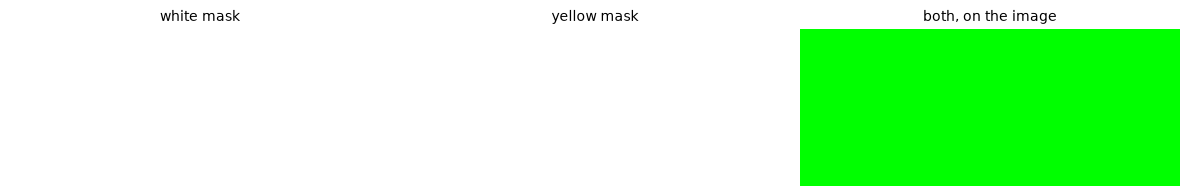

In [83]:
# TODO: fill in the four bounds. Each is [H, S, V].
#
# Use the numbers you printed in section 2 as a starting point, then adjust
# while watching the pictures below.
WHITE_LOW,  WHITE_HIGH  = np.array([0, 0, 0]), np.array([180, 255, 255])
YELLOW_LOW, YELLOW_HIGH = np.array([0, 0, 0]), np.array([180, 255, 255])

mask_white  = cv2.inRange(hsv, WHITE_LOW,  WHITE_HIGH)
mask_yellow = cv2.inRange(hsv, YELLOW_LOW, YELLOW_HIGH)

overlay = cropped.copy()
overlay[mask_white  > 0] = (255, 0, 255)   # magenta
overlay[mask_yellow > 0] = (0, 255, 0)     # green, NOTE: this will overwrite magenta if both are true!
show(mask_white, mask_yellow, overlay,
     titles=["white mask", "yellow mask", "both, on the image"], size=4)

### Red, and why it needs two ranges

Hue is an **angle**, and OpenCV cuts that circle open at 0. Red sits exactly on
the cut - some red pixels land near H=0 and some near H=179. No single
`low <= H <= high` pair can catch both, so red takes two ranges OR'd together.

NOTE: You may not need both ranges in practice but it is good to know how to handle it!

In [ ]:
# TODO: Find two ranges, one at each end of the hue circle, combined with
# cv2.bitwise_or. Red near H=0 and red near H=179 are the same color.
RED_LOW_1, RED_HIGH_1 = np.array([0, 0, 0]), np.array([180, 255, 255])
RED_LOW_2, RED_HIGH_2 = np.array([0, 0, 0]), np.array([180, 255, 255])

# TODO: Write your cv2.inRange calls and combine the two masks with cv2.bitwise_or

mask_red =  # store the combined mask here!

show(mask_red, titles=["red mask"], size=4)

## 4. Morphology - and the real reason for it

`erode` shrinks a mask, `dilate` grows it. Eroding first removes isolated
speckle; dilating afterwards puts the surviving regions back to roughly their
original size. Both slide a small shape called a **kernel** (here an ellipse
`KERNEL_SIZE` pixels across) over the mask: erode keeps a pixel only if the
kernel centered on it fits entirely inside the mask, and dilate turns a pixel on
if the kernel centered on it touches any of the mask - so a bigger kernel eats
away or adds more per pass.

But there is a second reason to dilate, and it is the one that actually
matters. In section 6 you are going to intersect these masks with **edges**,
and an edge sits on the *boundary* of a colored region - right at the mask's
rim, or a pixel outside it. An undilated mask barely touches its own edges.
Dilating past the original size is what makes the intersection find anything at
all.

In [ ]:
# TODO: Tune these parameters
KERNEL_SIZE = 
ERODE_ITERS = 
DILATE_ITERS = 

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (KERNEL_SIZE, KERNEL_SIZE))

def clean(mask):
    # TODO: erode to drop speckle, then dilate. Remember the second reason for
    # the dilation - the mask has to reach out over the Canny edges you find in
    # section 6.
    m = mask          # TODO: cv2.erode(...)
    m = m             # TODO: cv2.dilate(...)
    return m

clean_white  = clean(mask_white)
clean_yellow = clean(mask_yellow)
clean_red    = clean(mask_red)

show(mask_white, clean_white, titles=["white, raw", "white, eroded then dilated"], size=4.5)
print(f"white  {int(mask_white.sum()//255):5d} -> {int(clean_white.sum()//255):5d} px")
print(f"yellow {int(mask_yellow.sum()//255):5d} -> {int(clean_yellow.sum()//255):5d} px")

## 5. Edges

`cv2.Canny` finds places where brightness changes sharply. It takes two
thresholds: gradients above the high one definitely start an edge, gradients
between the two only continue an edge already started, and anything below the
low one is discarded.

**Canny runs once, on the whole image - not once per color.** An edge is an
edge; the color masks are what sort them out afterwards.

Low thresholds trace every speck of texture in the road surface. High ones keep
only the strongest boundaries and start losing the far end of the lane
markings, where the contrast is weakest. You want the lane edges crisp and the
road texture mostly gone.

Blurring first with `cv2.GaussianBlur(image, kernel_size, standard_deviation)` smooths out that texture, so Canny can lock onto the lane edges.

In [ ]:
# TODO: Tune these parameters
CANNY_LOW = 
CANNY_HIGH = 
blurred = cv2.GaussianBlur(cropped, (5, 5), 0)
edges = cv2.Canny(blurred, CANNY_LOW, CANNY_HIGH, apertureSize=3)
show(blurred, edges, titles=["blurred", f"Canny({CANNY_LOW}, {CANNY_HIGH})"], size=5)

## 6. Color AND edges - the step that makes this work

Now we can put our color and edge detection together!

You have edges, but no idea which marking each one belongs to. You have color
masks, but they are solid blobs, and a line-fitter given a solid blob returns
nonsense. **`cv2.bitwise_and` of the two gives you the outline of one specific
marking**, which is exactly what a line-fitter wants.

Try it on the white mask below.

In [ ]:
white_edges = # TODO use cv2.bitwise_and to combine the clean white mask with the edges

white_lines = cv2.HoughLinesP(white_edges, rho=1, theta=np.pi / 180, threshold=4,
                            minLineLength=3, maxLineGap=3)

show(cv2.cvtColor(white_edges, cv2.COLOR_GRAY2BGR), draw(cropped, white_lines),
     titles=["mask AND edges",
             f"Hough on the intersection"], size=4)

## 7. The Hough transform, and its four knobs

`HoughLinesP` works by letting every lit pixel vote for all the lines that
could pass through it, and returning the lines with enough votes.

| parameter | what it does | too low | too high |
|---|---|---|---|
| `threshold` | votes needed to accept a line | spurious lines | misses faint markings |
| `minLineLength` | shortest segment kept | noise fragments | loses distant markings |
| `maxLineGap` | gap that can be bridged | dashes come out fragmented | unrelated markings get joined |
| `rho`, `theta` | resolution of the vote grid | slow, fragmented | coarse, inaccurate |

### What you are aiming for

<img src="example_hough.png" alt="Example Hough output: white, yellow and red segments along each lane marking" width="600">

*A well-tuned result, all three colors. Every marking is traced along its edges by a few clean segments, without
a cloud of short fragments across the road. The magenta dots and green normals come from orienting the segments
in section 8 - for now, judge just the colored lines.*

In [ ]:
# COMPARE TWO sets of Hough parameters
# TODO change these parameters to see how the number of segments changes.
HOUGH_PARMS1 = (2, 7, 3)   # threshold, minLineLength, maxLineGap
HOUGH_PARMS2 = (8, 3, 3)   # threshold, minLineLength, maxLineGap

fig, axes = plt.subplots(1, 2, figsize=(16, 3.2))

l1 = cv2.HoughLinesP(white_edges, rho=1, theta=np.pi / 180, threshold=HOUGH_PARMS1[0],
                            minLineLength=HOUGH_PARMS1[1], maxLineGap=HOUGH_PARMS1[2])
axes[0].imshow(cv2.cvtColor(draw(cropped, l1), cv2.COLOR_BGR2RGB))
axes[0].set_title(f"threshold={HOUGH_PARMS1[0]}: {len(l1)} segments", fontsize=9)
axes[0].axis("off")

l2 = cv2.HoughLinesP(white_edges, rho=1, theta=np.pi / 180, threshold=HOUGH_PARMS2[0],
                            minLineLength=HOUGH_PARMS2[1], maxLineGap=HOUGH_PARMS2[2])

axes[1].imshow(cv2.cvtColor(draw(cropped, l2), cv2.COLOR_BGR2RGB))
axes[1].set_title(f"threshold={HOUGH_PARMS2[0]}: {len(l2)} segments", fontsize=9)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# TODO: settle on the values you liked above. All three colors then go
# through the same bitwise_and + Hough.
HOUGH_PARMS =   # TODO (threshold, minLineLength, maxLineGap)
masks = {"WHITE": clean_white, "YELLOW": clean_yellow, "RED": clean_red}
detections = {}

for name, m in masks.items():
    lines = cv2.HoughLinesP(cv2.bitwise_and(m, edges), rho=1, theta=np.pi / 180,
                            threshold=HOUGH_PARMS[0],
                            minLineLength=HOUGH_PARMS[1],
                            maxLineGap=HOUGH_PARMS[2])
    # Flatten to Nx4 (x1, y1, x2, y2) - the shape orient() below expects.
    detections[name] = None if lines is None else lines.reshape(-1, 4)

# One panel per color, drawn on the cropped image.
show(draw(cropped, detections["WHITE"], color=(255, 0, 255)),
     draw(cropped, detections["YELLOW"], color=(0, 255, 0)),
     draw(cropped, detections["RED"], color=(0, 0, 255)),
     titles=["WHITE", "YELLOW", "RED"], size=4)

## 8. Orienting the segments

`HoughLinesP` hands back two endpoints **in no particular order**. For drawing
a picture that is fine. For the lane filter downstream it is a problem, and
here is why.

A white lane marking has *two* edges: the one facing the road you are driving
on, and the one facing away. Section 6 found both. To the Hough transform they
are identical - two parallel lines a few centimeters apart. But they mean
completely different things about where the robot is, and Duckietown's lane
filter tells them apart by **the order of the two endpoints**.

So a segment needs a direction. The way to find one is to look at which side
the paint is on:

1. Take the segment's midpoint.
2. Step a couple of pixels along the **perpendicular**, both ways.
3. Look at the color mask at both spots. Paint on one side and not the other
   tells you which way the marking faces.
4. Swap the endpoints wherever needed so that this is consistent for every
   segment.

For a segment from $(x_1, y_1)$ to $(x_2, y_2)$ of length $L$, the unit
perpendicular is

$$ \left( \frac{y_2 - y_1}{L},\ \frac{x_1 - x_2}{L} \right) $$

**You do not need to change the code below** - your node already has it, as
`_orient`.

In [ ]:
PROBE_PX = 2

def orient(lines, mask, probe=PROBE_PX, do_swap=True):
    '''Order each segment's endpoints so they record which side the paint is on.

    Reorders `lines` in place and returns an Nx2 array of unit normals.
    '''
    if len(lines) == 0:
        return np.zeros((0, 2))

    length = np.sum((lines[:, 0:2] - lines[:, 2:4]) ** 2, axis=1, keepdims=True) ** 0.5
    length[length == 0] = 1.0

    dx = 1.0 * (lines[:, 3:4] - lines[:, 1:2]) / length     # the perpendicular
    dy = 1.0 * (lines[:, 0:1] - lines[:, 2:3]) / length

    cx = (lines[:, 0:1] + lines[:, 2:3]) / 2.0
    cy = (lines[:, 1:2] + lines[:, 3:4]) / 2.0

    def clamp(vals, bound):
        out = vals.astype(int)
        np.clip(out, 0, bound - 1, out=out)
        return out

    x3, y3 = clamp(cx - probe * dx, mask.shape[1]), clamp(cy - probe * dy, mask.shape[0])
    x4, y4 = clamp(cx + probe * dx, mask.shape[1]), clamp(cy + probe * dy, mask.shape[0])

    # +1 where the first probe is on paint and the second is not, else -1.
    signs = (np.logical_and(mask[y3, x3] > 0, mask[y4, x4] == 0)).astype(int) * 2 - 1
    normals = np.hstack([dx, dy]) * signs

    if do_swap:
        flip = ((lines[:, 2] - lines[:, 0]) * normals[:, 1]
                - (lines[:, 3] - lines[:, 1]) * normals[:, 0]) > 0
        lines[flip] = lines[flip][:, [2, 3, 0, 1]]

    return normals

# How many segments does this actually change?
for name, lines in detections.items():
    if lines is None or len(lines) == 0:
        continue
    before = lines.copy()
    normals = orient(lines, masks[name])
    changed = int((before != lines).any(axis=1).sum())
    cross = ((lines[:, 2] - lines[:, 0]) * normals[:, 1]
             - (lines[:, 3] - lines[:, 1]) * normals[:, 0])
    print(f"{name:7s} {len(lines):3d} segments, {changed:3d} reordered "
          f"({100*changed/len(lines):4.0f}%), handedness violations after: "
          f"{int((cross > 1e-9).sum())}")

In [ ]:
# Green arrows point from each segment's midpoint *out of the paint* - the side
# the probe found empty. Within one marking they should all agree; where they
# disagree, both probes landed on the same side and the answer was a coin flip.
annotated = cropped.copy()
DRAW_COLORS = {"WHITE": (255, 255, 255), "YELLOW": (0, 255, 255), "RED": (0, 0, 255)}
SCALE = 5          # upscale factor for the display
ARROW_PX = 6       # arrow length, in original (pre-upscale) pixels

normals_by_color = {}
arrows = []
for name, lines in detections.items():
    if lines is None:
        continue
    n = orient(lines, masks[name], do_swap=False) if len(lines) else np.zeros((0, 2))
    normals_by_color[name] = n
    for (x1, y1, x2, y2), nv in zip(lines, n):
        cv2.line(annotated, (x1, y1), (x2, y2), DRAW_COLORS[name], 1, cv2.LINE_AA)
        cv2.circle(annotated, (x1, y1), 1, (255, 0, 255), -1)
        mx, my = (x1 + x2) / 2.0, (y1 + y2) / 2.0
        arrows.append(((mx, my), nv))

big = cv2.resize(annotated, (annotated.shape[1] * SCALE, annotated.shape[0] * SCALE),
                 interpolation=cv2.INTER_NEAREST)

# Drawn after the upscale so the arrowheads are big enough to read.
for (mx, my), nv in arrows:
    tail = (int(round(mx * SCALE)), int(round(my * SCALE)))
    tip = (int(round((mx + ARROW_PX * nv[0]) * SCALE)),
           int(round((my + ARROW_PX * nv[1]) * SCALE)))
    if tip != tail:
        cv2.arrowedLine(big, tail, tip, (0, 255, 0), 2, cv2.LINE_AA, tipLength=0.4)

show(big, titles=["segments, first endpoint in magenta, outward normal in green"], size=9)
